Pre-Actividad
(Practicar syntax)

In [1]:
import yfinance as yf

microsoft = yf.Ticker("MSFT")
hist = microsoft.history(period="1d")
print("precio de apertura", float(hist["Open"].iloc[-1]))
print("precio actual", float(microsoft.fast_info["last_price"]))

precio de apertura 400.7200012207031
precio actual 395.54998779296875


Para obtener los precios historicos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf

2026-03-13 16:18:56.159483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
from pathlib import Path


def get_prices(share_symbol, start_date, end_date, cache_filename):
    cache_path = Path(cache_filename)

    try:
        return np.load(cache_path).tolist()
    except FileNotFoundError:
        ticker = yf.Ticker(share_symbol)
        stock_hist = ticker.history(start=start_date, end=end_date)

        stock_prices = stock_hist["Open"].dropna().to_numpy(dtype=float)

        cache_path.parent.mkdir(parents=True, exist_ok=True)  # prob se puede arr
        np.save(cache_path, stock_prices)

        return stock_prices.tolist()

Para Graficar

In [10]:
import matplotlib.pyplot as plt

def plot_prices(prices):
    plt.title("Opening stock prices")
    plt.xlabel("day")
    plt.ylabel("price ($)")
    plt.plot(prices)
    plt.show()

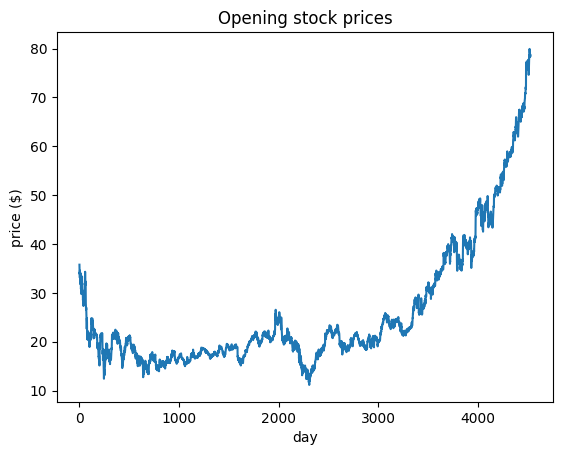

In [11]:
prices = get_prices('MSFT', '2000-01-01', '2017-12-31', 'msft_prices.npy')
plot_prices(prices)


Def Politicas de Decision

In [13]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass


class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action